# 数据集加载及预处理

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [2]:
for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 1])


In [3]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [4]:
# 定义回归模型
class HousePriceModel(nn.Module):
    def __init__(self, input_size, hidden_size=30, output_size=1):
        super(HousePriceModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建模型实例
input_size = X.shape[1]  # 特征维度
model = HousePriceModel(input_size=input_size, hidden_size=30, output_size=1)

print(f"模型结构:")
print(model)
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")


模型结构:
HousePriceModel(
  (fc1): Linear(in_features=8, out_features=30, bias=True)
  (fc2): Linear(in_features=30, out_features=1, bias=True)
  (relu): ReLU()
)

模型参数数量: 301


In [5]:
# 导入训练模块
from wangdao_train import Trainer, EarlyStopping, ModelCheckpoint


# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 初始化损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数，适用于回归任务
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 初始化早停对象
early_stopping = EarlyStopping(
    patience=10,      # 容忍10个评估周期没有改善
    min_delta=0.001,  # 最小改善阈值
    mode='min'        # 监控val_loss，越小越好
)

# 初始化模型保存对象
model_checkpoint = ModelCheckpoint(
    filepath='./checkpoints/regression_model_epoch_{epoch}.ckpt',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    min_delta=0.001
)

# 创建训练器
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=50,  # 每50个batch评估一次
    early_stopping=early_stopping,
    model_checkpoint=model_checkpoint
)

# 开始训练
print("开始训练...")
trainer.train_regression(num_epochs=100)


使用设备: cpu
开始训练...
[Step 50] Val Loss: 3.3456
[Step 100] Val Loss: 1.9887
[Step 150] Val Loss: 1.2557
[Step 200] Val Loss: 0.9339
Epoch [1/100]  Train Loss: 2.2764
[Step 250] Val Loss: 0.8321
[Step 300] Val Loss: 0.7727
[Step 350] Val Loss: 0.7331
[Step 400] Val Loss: 0.6948
[Step 450] Val Loss: 0.6618
Epoch [2/100]  Train Loss: 0.7612
[Step 500] Val Loss: 0.6342
[Step 550] Val Loss: 0.6073
[Step 600] Val Loss: 0.5838
[Step 650] Val Loss: 0.5617
Epoch [3/100]  Train Loss: 0.5978
[Step 700] Val Loss: 0.5425
[Step 750] Val Loss: 0.5263
[Step 800] Val Loss: 0.5167
[Step 850] Val Loss: 0.5030
[Step 900] Val Loss: 0.4936
Epoch [4/100]  Train Loss: 0.5102
[Step 950] Val Loss: 0.4844
[Step 1000] Val Loss: 0.4773
[Step 1050] Val Loss: 0.4724
[Step 1100] Val Loss: 0.4651
Epoch [5/100]  Train Loss: 0.4679
[Step 1150] Val Loss: 0.4616
[Step 1200] Val Loss: 0.4572
[Step 1250] Val Loss: 0.4534
[Step 1300] Val Loss: 0.4496
[Step 1350] Val Loss: 0.4471
Epoch [6/100]  Train Loss: 0.4452
[Step 1400] Val

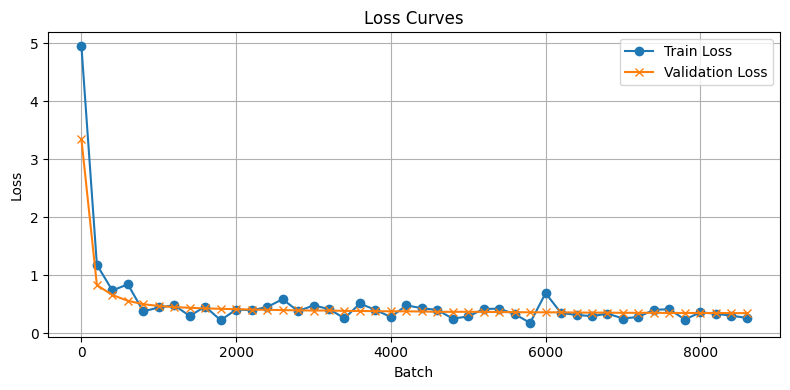

In [6]:
trainer.plot_curves(200)